In [1]:
import sys
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import random

In [2]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [3]:
# Example usage:
df_metadata = load_sweep_metadata(
    sweep_base_dirs=
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-cartpole_swingup-noncentered-initial_conditions_seeds_sweep",
    json_file_name="episode_metadata.json")


Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-cartpole_swingup-noncentered-initial_conditions_seeds_sweep: 100%|██████████| 275/275 [00:00<00:00, 796.74it/s]

Found 275 configurations


In [4]:
df = load_data(
    df_metadata,
    #cart_position=0.,
    episode_file_name="episode_data.pkl")

Found 275 configurations


100%|██████████| 275/275 [00:01<00:00, 239.34it/s]


In [5]:
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())
z.shape, obs.shape, actions.shape

((137500, 512), (137500, 5), (137500, 1))

In [14]:
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

random.seed(0)

# Train-test split
X_test = z[:5500]
X_train = z[5500:]

# Dictionary to store results for both targets
results_dict = {}

# Train for actions
y_test_actions = actions[:5500]
y_train_actions = actions[5500:]

lr_actions = LinearRegression()
lr_actions.fit(X_train, y_train_actions)
y_pred_actions = lr_actions.predict(X_test)
r2_actions = r2_score(y_test_actions, y_pred_actions)
print(f"Linear Regression R2 Score (Actions): {r2_actions}")

results_dict['actions'] = {
    'coef': lr_actions.coef_,
    'intercept': lr_actions.intercept_,
    'r2': r2_actions
}

# Train for observations
y_test_obs = obs[:5500]
y_train_obs = obs[5500:]

lr_obs = LinearRegression()
lr_obs.fit(X_train, y_train_obs)
y_pred_obs = lr_obs.predict(X_test)
r2_obs = r2_score(y_test_obs, y_pred_obs)
print(f"Linear Regression R2 Score (Observations): {r2_obs}")

results_dict['position'] = {
    'coef': lr_obs.coef_[0, :],
    'intercept': lr_obs.intercept_,
    'r2': r2_obs
}

n_random = 3

for i in range(n_random):
    results_dict[f'random_{i}'] = {
        'coef': np.random.randn(z.shape[1]) * 0.3,
        'intercept': 0,
        'r2': 0
    }

Linear Regression R2 Score (Actions): 0.7484629154205322
Linear Regression R2 Score (Observations): 0.9973715543746948


In [15]:
results_dict.keys()

dict_keys(['actions', 'position', 'random_0', 'random_1', 'random_2'])

<StemContainer object of 3 artists>

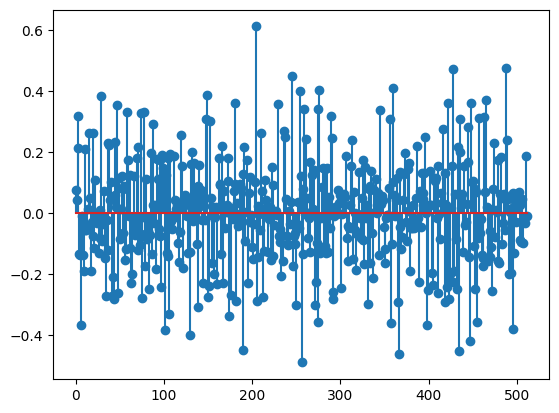

In [17]:
plt.stem(results_dict['position']['coef'])

In [18]:
# Save coefficients to file
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/25-12-15-control-position-cartpole-swingup-noncentered/w_lr_coefs_noncentered.pkl',
        'wb') as f:
    pickle.dump(results_dict, f)

print("Coefficients saved to linear_regression_coefficients.pkl")


Coefficients saved to linear_regression_coefficients.pkl
